<a href="https://colab.research.google.com/github/salmakhale/ML-Data-Analysis/blob/main/Bank_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x=pd.read_csv('/content/df_X.csv')

In [ ]:
y=pd.read_csv('/content/df_y.csv')

In [ ]:
df=pd.concat([x,y],axis=1)

In [ ]:
df.head()

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,Unnamed: 0,y
0,0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,0,no
1,1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,1,no
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,2,no
3,3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,3,no
4,4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,4,no


In [ ]:
df.shape

(45211, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   45211 non-null  int64 
 1   age          45211 non-null  int64 
 2   job          44923 non-null  object
 3   marital      45211 non-null  object
 4   education    43354 non-null  object
 5   default      45211 non-null  object
 6   balance      45211 non-null  int64 
 7   housing      45211 non-null  object
 8   loan         45211 non-null  object
 9   contact      32191 non-null  object
 10  day_of_week  45211 non-null  int64 
 11  month        45211 non-null  object
 12  duration     45211 non-null  int64 
 13  campaign     45211 non-null  int64 
 14  pdays        45211 non-null  int64 
 15  previous     45211 non-null  int64 
 16  poutcome     8252 non-null   object
 17  Unnamed: 0   45211 non-null  int64 
 18  y            45211 non-null  object
dtypes: int64(9), object(10)
m

In [ ]:
df.columns

Index(['Unnamed: 0', 'age', 'job', 'marital', 'education', 'default',
       'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month',
       'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'Unnamed: 0',
       'y'],
      dtype='object')

In [ ]:
df.isnull().sum().sort_values(ascending = False).head(10)

,0
poutcome,36959
contact,13020
education,1857
job,288
month,0
Unnamed: 0,0
previous,0
pdays,0
campaign,0
duration,0


In [ ]:
df.duplicated().sum()

0

In [ ]:
#df.drop('Unnamed: 0' ,axis=1,inplace=True)
columns_to_drop = [ 'contact', 'day_of_week', 'pdays']
df.drop(columns=columns_to_drop)

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,month,duration,campaign,previous,poutcome,Unnamed: 0,y
0,0,58,management,married,tertiary,no,2143,yes,no,may,261,1,0,NaN,0,no
1,1,44,technician,single,secondary,no,29,yes,no,may,151,1,0,NaN,1,no
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,may,76,1,0,NaN,2,no
3,3,47,blue-collar,married,NaN,no,1506,yes,no,may,92,1,0,NaN,3,no
4,4,33,NaN,single,NaN,no,1,no,no,may,198,1,0,NaN,4,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,45206,51,technician,married,tertiary,no,825,no,no,nov,977,3,0,NaN,45206,yes
45207,45207,71,retired,divorced,primary,no,1729,no,no,nov,456,2,0,NaN,45207,yes
45208,45208,72,retired,married,secondary,no,5715,no,no,nov,1127,5,3,success,45208,yes
45209,45209,57,blue-collar,married,secondary,no,668,no,no,nov,508,4,0,NaN,45209,no


In [ ]:
df.shape

(45211, 19)

In [ ]:
df.describe()

,Unnamed: 0,age,balance,day_of_week,duration,campaign,pdays,previous,Unnamed: 0
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,22605.000000,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,22605.000000
std,13051.435847,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,13051.435847
min,0.000000,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,11302.500000,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,11302.500000
50%,22605.000000,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,22605.000000
75%,33907.500000,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,33907.500000
max,45210.000000,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,45210.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   45211 non-null  int64 
 1   age          45211 non-null  int64 
 2   job          44923 non-null  object
 3   marital      45211 non-null  object
 4   education    43354 non-null  object
 5   default      45211 non-null  object
 6   balance      45211 non-null  int64 
 7   housing      45211 non-null  object
 8   loan         45211 non-null  object
 9   contact      32191 non-null  object
 10  day_of_week  45211 non-null  int64 
 11  month        45211 non-null  object
 12  duration     45211 non-null  int64 
 13  campaign     45211 non-null  int64 
 14  pdays        45211 non-null  int64 
 15  previous     45211 non-null  int64 
 16  poutcome     8252 non-null   object
 17  Unnamed: 0   45211 non-null  int64 
 18  y            45211 non-null  object
dtypes: int64(9), object(10)
m

In [ ]:
df['job'].fillna(df['job'].mode()[0], inplace=True)


In [ ]:
df['education'].fillna(df['education'].mode()[0], inplace=True)


In [ ]:
df['contact'].fillna('unknown', inplace=True)
df['poutcome'].fillna('unknown', inplace=True)


In [ ]:
print(df.isnull().sum())


Unnamed: 0     0
age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day_of_week    0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
Unnamed: 0     0
y              0
dtype: int64


In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

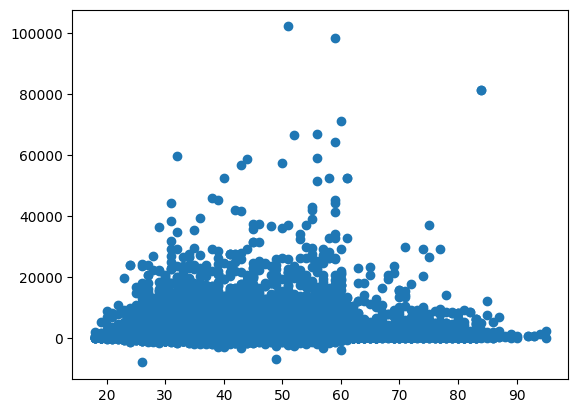

In [ ]:
#relation between age ,balance
plt.scatter(df['age'],df['balance'])

<BarContainer object of 45211 artists>

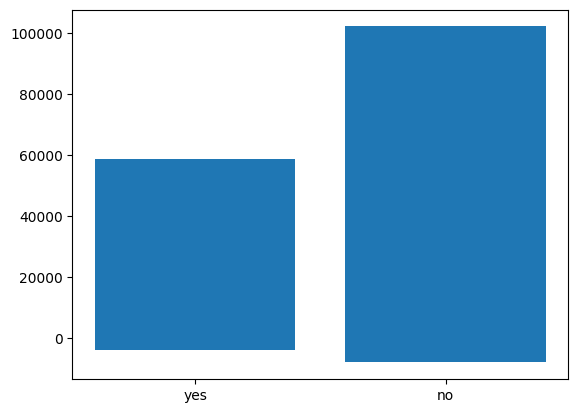

In [ ]:
#relation between balance ,housing
plt.bar(df['housing'],df['balance'])



([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'management'),
  Text(1, 0, 'technician'),
  Text(2, 0, 'entrepreneur'),
  Text(3, 0, 'blue-collar'),
  Text(4, 0, 'retired'),
  Text(5, 0, 'admin.'),
  Text(6, 0, 'services'),
  Text(7, 0, 'self-employed'),
  Text(8, 0, 'unemployed'),
  Text(9, 0, 'housemaid'),
  Text(10, 0, 'student')])

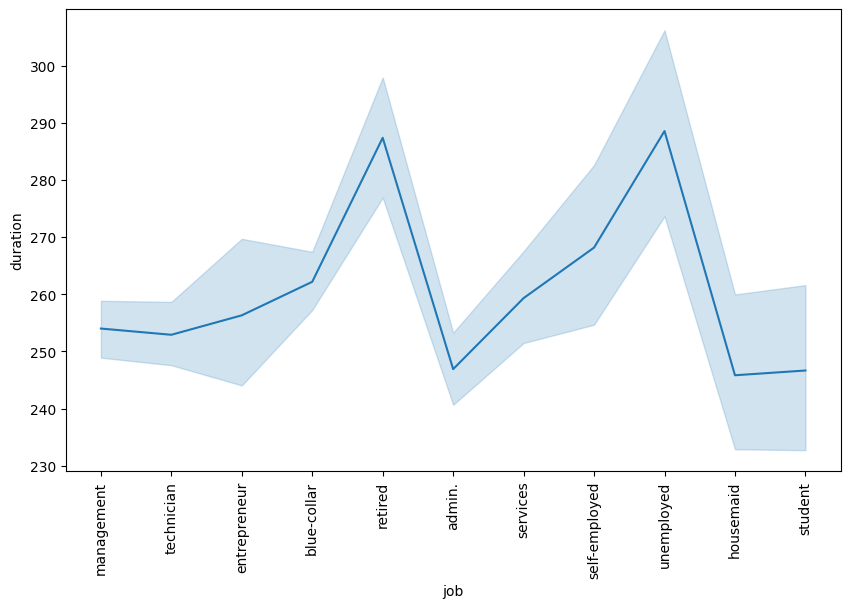

In [ ]:
#relation between job, duration
plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x='job', y='duration')
plt.xticks(rotation=90)


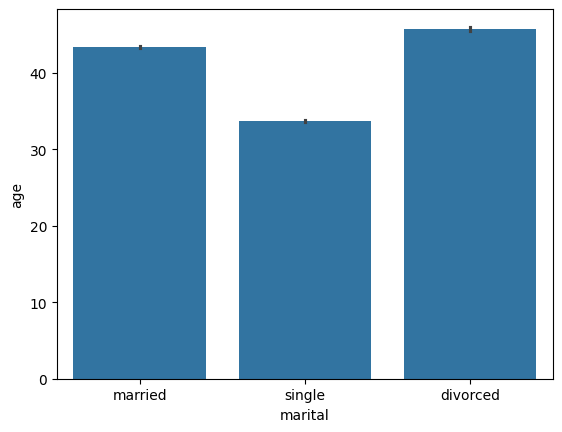

In [ ]:
sns.barplot(x='marital', y='age', data=df)
plt.show()

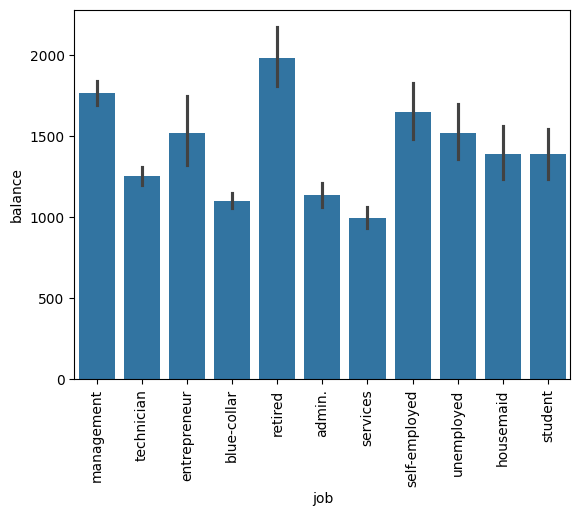

In [ ]:
sns.barplot(x='job', y='balance', data=df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
corr_matrix = df[['age', 'balance', 'duration', 'campaign', 'previous']].corr()
corr_matrix

,age,balance,duration,campaign,previous
age,1.000000,0.097783,-0.004648,0.004760,0.001288
balance,0.097783,1.000000,0.021560,-0.014578,0.016674
duration,-0.004648,0.021560,1.000000,-0.084570,0.001203
campaign,0.004760,-0.014578,-0.084570,1.000000,-0.032855
previous,0.001288,0.016674,0.001203,-0.032855,1.000000


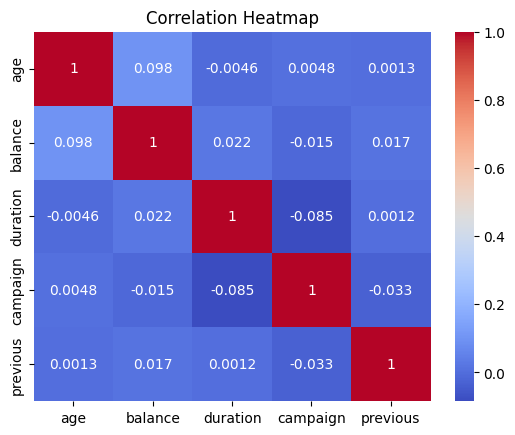

In [ ]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

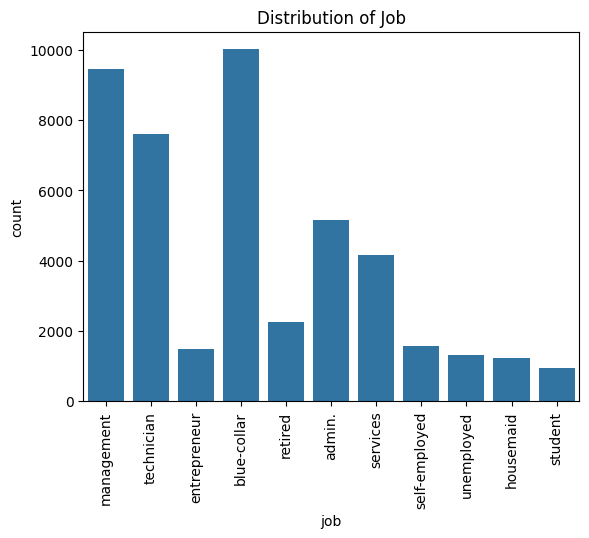

In [ ]:
sns.countplot(x='job', data=df)
plt.xticks(rotation=90)
plt.title('Distribution of Job')
plt.show()

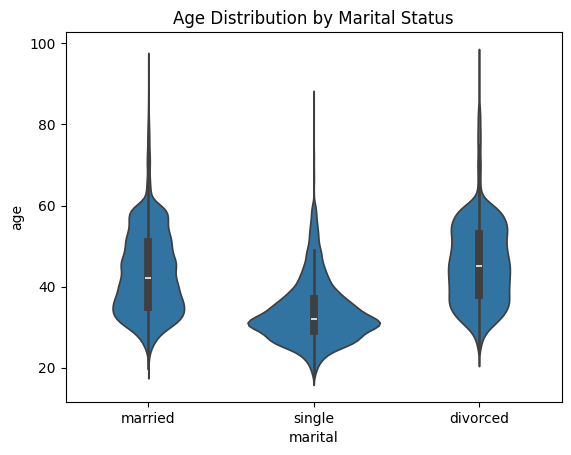

In [ ]:
sns.violinplot(x='marital', y='age', data=df)
plt.title('Age Distribution by Marital Status')
plt.show()

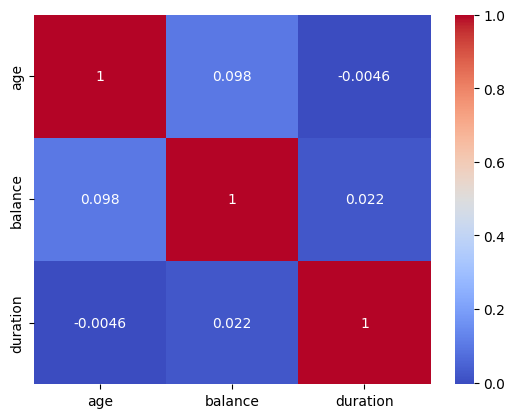

In [ ]:
corr_matrix = df[['age', 'balance', 'duration']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

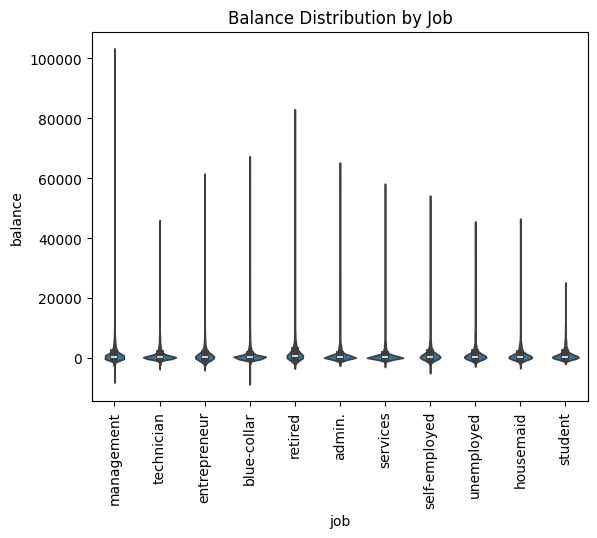

In [ ]:
sns.violinplot(x='job', y='balance', data=df)
plt.xticks(rotation=90)
plt.title('Balance Distribution by Job')
plt.show()

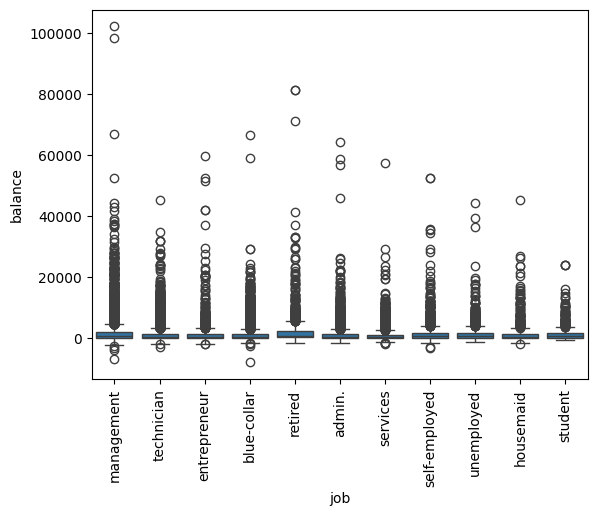

In [ ]:
sns.boxplot(x='job', y='balance', data=df)
plt.xticks(rotation=90)
plt.show()

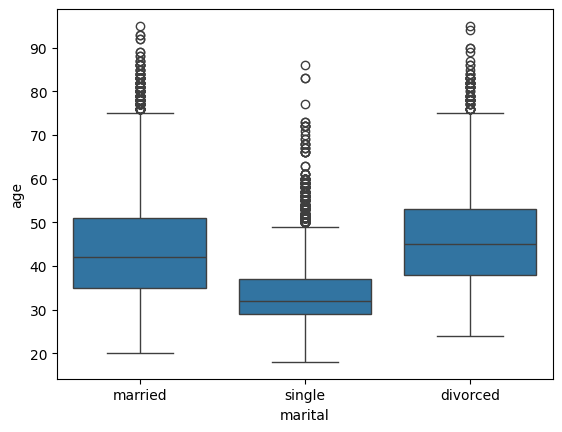

In [ ]:
sns.boxplot(x='marital', y='age', data=df)
plt.show()

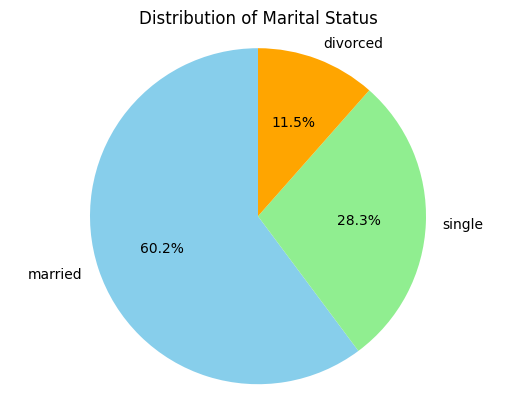

In [ ]:
marital_counts = df['marital'].value_counts()
plt.pie(marital_counts, labels=marital_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'orange'])
plt.title('Distribution of Marital Status')
plt.axis('equal')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   45211 non-null  int64 
 1   age          45211 non-null  int64 
 2   job          45211 non-null  object
 3   marital      45211 non-null  object
 4   education    45211 non-null  object
 5   default      45211 non-null  object
 6   balance      45211 non-null  int64 
 7   housing      45211 non-null  object
 8   loan         45211 non-null  object
 9   contact      45211 non-null  object
 10  day_of_week  45211 non-null  int64 
 11  month        45211 non-null  object
 12  duration     45211 non-null  int64 
 13  campaign     45211 non-null  int64 
 14  pdays        45211 non-null  int64 
 15  previous     45211 non-null  int64 
 16  poutcome     45211 non-null  object
 17  Unnamed: 0   45211 non-null  int64 
 18  y            45211 non-null  object
dtypes: int64(9), object(10)
m

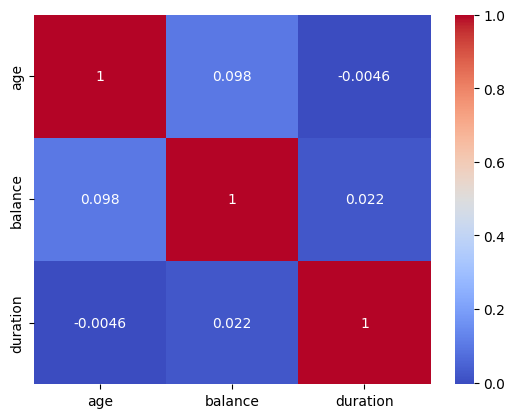

In [ ]:
corr_matrix = df[['age', 'balance', 'duration']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

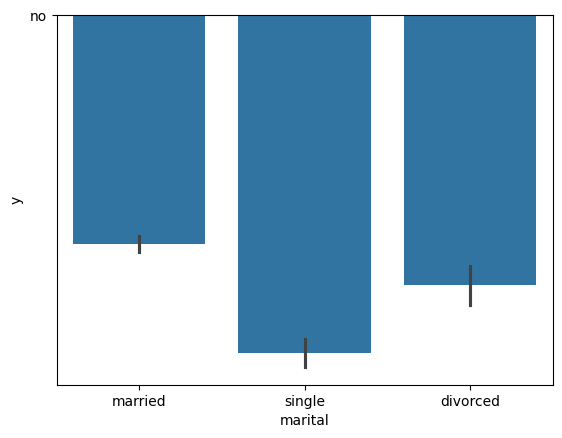

In [ ]:
sns.barplot(x='marital', y='y', data=df)
plt.show()


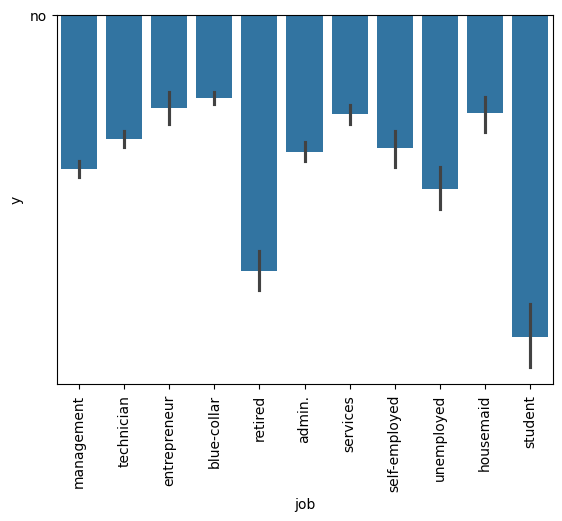

In [ ]:
sns.barplot(x='job', y='y', data=df)
plt.xticks(rotation=90)
plt.show()

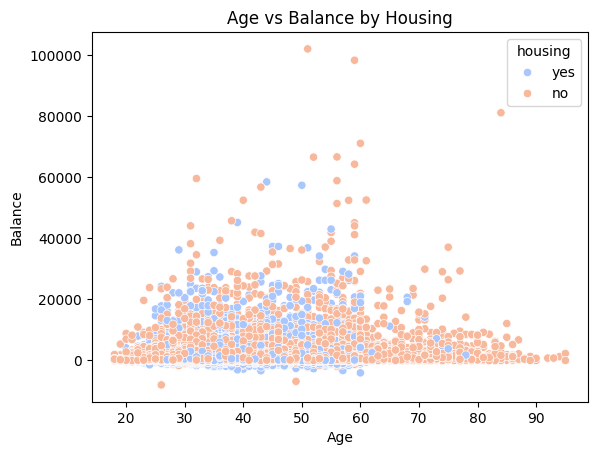

In [ ]:
sns.scatterplot(x='age', y='balance', hue='housing', data=df, palette='coolwarm')
plt.title('Age vs Balance by Housing')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.show()

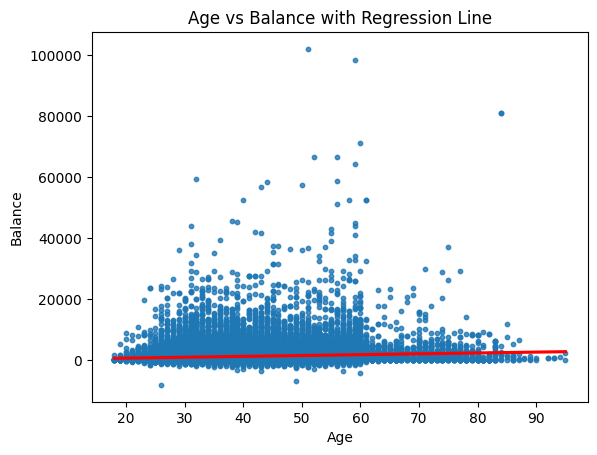

In [ ]:
sns.regplot(x='age', y='balance', data=df, scatter_kws={'s':10}, line_kws={'color':'red'})
plt.title('Age vs Balance with Regression Line')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.show()

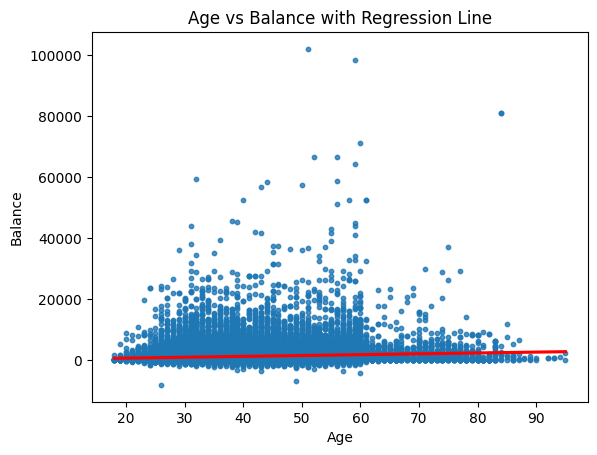

In [ ]:
sns.regplot(x='age', y='balance', data=df, scatter_kws={'s':10}, line_kws={'color':'red'})
plt.title('Age vs Balance with Regression Line')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.show()

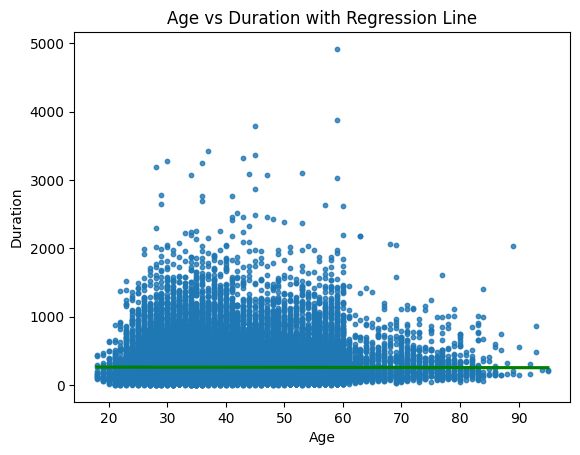

In [ ]:
sns.regplot(x='age', y='duration', data=df, scatter_kws={'s':10}, line_kws={'color':'green'})
plt.title('Age vs Duration with Regression Line')
plt.xlabel('Age')
plt.ylabel('Duration')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   45211 non-null  int64 
 1   age          45211 non-null  int64 
 2   job          45211 non-null  object
 3   marital      45211 non-null  object
 4   education    45211 non-null  object
 5   default      45211 non-null  object
 6   balance      45211 non-null  int64 
 7   housing      45211 non-null  object
 8   loan         45211 non-null  object
 9   contact      45211 non-null  object
 10  day_of_week  45211 non-null  int64 
 11  month        45211 non-null  object
 12  duration     45211 non-null  int64 
 13  campaign     45211 non-null  int64 
 14  pdays        45211 non-null  int64 
 15  previous     45211 non-null  int64 
 16  poutcome     45211 non-null  object
 17  Unnamed: 0   45211 non-null  int64 
 18  y            45211 non-null  object
dtypes: int64(9), object(10)
m

In [ ]:
df['job'].head()

,job
0,management
1,technician
2,entrepreneur
3,blue-collar
4,blue-collar


In [ ]:
for col in ['job','marital','education','default','housing','loan' ,'contact' ,'month' , 'poutcome']:
    print(f'number of column {col} is : ',df[col].nunique())
    print(f'number of column {col} is : ',df[col].unique())

number of column job is :  11
number of column job is :  ['management' 'technician' 'entrepreneur' 'blue-collar' 'retired' 'admin.'
 'services' 'self-employed' 'unemployed' 'housemaid' 'student']
number of column marital is :  3
number of column marital is :  ['married' 'single' 'divorced']
number of column education is :  3
number of column education is :  ['tertiary' 'secondary' 'primary']
number of column default is :  2
number of column default is :  ['no' 'yes']
number of column housing is :  2
number of column housing is :  ['yes' 'no']
number of column loan is :  2
number of column loan is :  ['no' 'yes']
number of column contact is :  3
number of column contact is :  ['unknown' 'cellular' 'telephone']
number of column month is :  12
number of column month is :  ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
number of column poutcome is :  4
number of column poutcome is :  ['unknown' 'failure' 'other' 'success']


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

lb=LabelEncoder()

for col in ['job','marital','education','default','housing']:
    df[col] = lb.fit_transform(df[col])

In [ ]:
df['marital'].unique()

array([1, 2, 0])

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

lb1=LabelEncoder()

for col in ['loan', 'contact', 'month', 'poutcome']:
    df[col] = lb1.fit_transform(df[col])

In [ ]:
#from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#df=pd.DataFrame(df)
#one_hot_encoder = OneHotEncoder(sparse=False, drop='first')
#df_encoded = one_hot_encoder.fit_transform(df[['loan', 'contact', 'month', 'poutcome']])
#df_encoded = pd.concat([df, df_encoded], axis=1).drop(columns=['loan', 'contact', 'month', 'poutcome'])
#print(df_encoded)



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   45211 non-null  int64 
 1   age          45211 non-null  int64 
 2   job          45211 non-null  int64 
 3   marital      45211 non-null  int64 
 4   education    45211 non-null  int64 
 5   default      45211 non-null  int64 
 6   balance      45211 non-null  int64 
 7   housing      45211 non-null  int64 
 8   loan         45211 non-null  int64 
 9   contact      45211 non-null  int64 
 10  day_of_week  45211 non-null  int64 
 11  month        45211 non-null  int64 
 12  duration     45211 non-null  int64 
 13  campaign     45211 non-null  int64 
 14  pdays        45211 non-null  int64 
 15  previous     45211 non-null  int64 
 16  poutcome     45211 non-null  int64 
 17  Unnamed: 0   45211 non-null  int64 
 18  y            45211 non-null  object
dtypes: int64(18), object(1)
m

In [ ]:
X = df.drop(columns=['y'])
y = df['y']

In [ ]:
print(X)


       Unnamed: 0  age  job  marital  education  default  balance  housing  \
0               0   58    4        1          2        0     2143        1   
1               1   44    9        2          1        0       29        1   
2               2   33    2        1          1        0        2        1   
3               3   47    1        1          1        0     1506        1   
4               4   33    1        2          1        0        1        0   
...           ...  ...  ...      ...        ...      ...      ...      ...   
45206       45206   51    9        1          2        0      825        0   
45207       45207   71    5        0          0        0     1729        0   
45208       45208   72    5        1          1        0     5715        0   
45209       45209   57    1        1          1        0      668        0   
45210       45210   37    2        1          1        0     2971        0   

       loan  contact  day_of_week  month  duration  campaign  p

In [ ]:
print(y)


0         no
1         no
2         no
3         no
4         no
        ... 
45206    yes
45207    yes
45208    yes
45209     no
45210     no
Name: y, Length: 45211, dtype: object


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
l1=LabelEncoder()
df['y']=l1.fit_transform(df['y'])

print(df['y'].head())
#OneHotEncoder = OneHotEncoder(sparse=False, drop='first')

#OneHotEncoder=OneHotEncoder.fit_transform(df['y'])

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64


,y
0,no
1,no
2,no
3,no
4,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


In [ ]:
from sklearn.preprocessing import MinMaxScaler
my_scaler = MinMaxScaler(feature_range=(0,1))
X_scaler_minMax = my_scaler.fit_transform(X)

In [ ]:
X_scaler_minMax.min(),X_scaler_minMax.max()

(0.0, 1.0)

In [ ]:
from sklearn.preprocessing import StandardScaler
my_scaler = StandardScaler()
X_scaler_SD = my_scaler.fit_transform(X)

In [ ]:
X_scaler_SD.min(),X_scaler_SD.max()

(-3.0811485466035458, 119.13598229870267)

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaler_RS = scaler.fit_transform(X)

In [ ]:
# Split into Input and Output Elements
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.20, random_state=100, stratify=y)

In [ ]:
print("X_train = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test  = ",X_test.shape ," y_test  = ", y_test.shape)

X_train =  (36168, 18)  y_train =  (36168,)
X_test  =  (9043, 18)  y_test  =  (9043,)


In [ ]:
from sklearn.linear_model import SGDClassifier

In [ ]:
sgd_model = SGDClassifier()
sgd_model.fit(X_train, y_train)

SGDClassifier()

In [ ]:
y_pred = sgd_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report

[[7095  890]
 [ 446  612]]


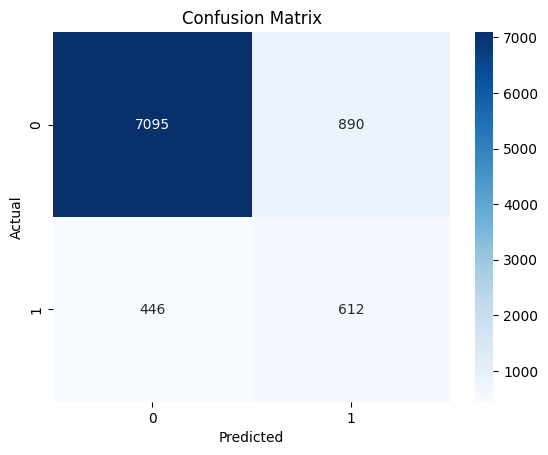

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d' ,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8522614176711268


In [ ]:
recall=cm[1,1]/(cm[1,0]+cm[1,1])
print(recall)

0.5784499054820416


In [ ]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

          no       0.89      0.94      0.91      7541
         yes       0.58      0.41      0.48      1502

    accuracy                           0.85      9043
   macro avg       0.73      0.67      0.70      9043
weighted avg       0.84      0.85      0.84      9043



In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.94      0.89      0.91      7985
         yes       0.41      0.58      0.48      1058

    accuracy                           0.85      9043
   macro avg       0.67      0.73      0.70      9043
weighted avg       0.88      0.85      0.86      9043



In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(criterion='gini',max_depth=None)

In [ ]:
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
dt.score(X_train,y_train)

1.0

In [ ]:
dt.score(X_test,y_test)

0.8833351763795201

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
RT= RandomForestClassifier(n_estimators=20 ,criterion='log_loss',max_depth=50)

In [ ]:
RT.fit(X_train,y_train)

RandomForestClassifier(criterion='log_loss', max_depth=50, n_estimators=20)

In [ ]:
RT.score(X_train , y_train)

0.9981198849811989

In [ ]:
RT.score(X_test,y_test)

0.9078845515868628

In [ ]:
RT.predict(X_test)

array(['no', 'yes', 'no', ..., 'no', 'no', 'no'], dtype=object)